# Topic Modeling sobre reseñas de Letterboxd

**Alfredo Martín López · Marcos Fernández Arévalo · Pedro Pérez Blanco**
Máster en Business Analytics (MUBA) — Universidad Pontificia Comillas ICADE

> **Ejecuta antes `01_preprocesamiento.ipynb`.** Este notebook parte de los `.parquet` que genera aquel, y que no están en el repositorio.

## Qué hacemos y en qué orden

Aplicamos **LDA (Latent Dirichlet Allocation)** para descubrir de qué habla la audiencia, y lo hacemos **dos veces**:

- **Experimento A — corpus multilingüe.** Todas las reseñas de películas de 2024, tal cual.
- **Experimento B — solo inglés.** Las mismas reseñas, filtradas por idioma detectado.

El experimento B no estaba en el trabajo original: nació de mirar los resultados de A y ver que **varios de los tópicos no eran temas sino idiomas**. En vez de dejarlo como limitación, lo convertimos en la pregunta siguiente: *¿qué pasa con los tópicos si quitamos el ruido multilingüe?*

Los dos experimentos usan **exactamente el mismo procedimiento**: mismo preprocesamiento, mismo barrido de K, misma métrica de coherencia y los mismos hiperparámetros. Lo único que cambia es el corpus de entrada.

In [1]:
# Dependencias en requirements.txt:
#     pip install -r requirements.txt
# !pip install -q gensim pyLDAvis wordcloud

In [2]:
# (incluido arriba)

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import warnings

# Se silencia SOLO este aviso concreto de una dependencia, no todos
warnings.filterwarnings("ignore", message=r"datetime\.datetime\.utcnow",
                        category=DeprecationWarning)

In [4]:
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

In [5]:
# (spaCy no hace falta aqui: el texto ya viene lematizado del notebook 1)

In [6]:
# Los dos corpus que genero el notebook 1
df = pd.read_parquet('letterboxd_reviews_preprocessed.parquet')
df_en = pd.read_parquet('letterboxd_reviews_preprocessed_en.parquet')

print(f"A · corpus multilingue: {len(df):,} reseñas, {df['title'].nunique():,} peliculas")
print(f"B · corpus solo ingles: {len(df_en):,} reseñas, {df_en['title'].nunique():,} peliculas "
      f"({len(df_en)/len(df)*100:.1f}% del anterior)")
print(f"\nIdiomas en A: {df['lang'].nunique()} · reparto de los 6 primeros:")
print(df['lang'].value_counts().head(6).to_string())

A · corpus multilingue: 11,968 reseñas, 8,470 peliculas
B · corpus solo ingles: 7,465 reseñas, 5,555 peliculas (62.4% del anterior)

Idiomas en A: 48 · reparto de los 6 primeros:
lang
en    7465
es     889
fr     763
pt     714
de     246
it     239


In [7]:
# La columna con el texto ya lematizado y sin stopwords
df['lemmatized_phrase_custom'] = df['lemmatized_review_custom']
df_en['lemmatized_phrase_custom'] = df_en['lemmatized_review_custom']
df[['title', 'lang', 'lemmatized_phrase_custom']].head()

,title,lang,lemmatized_phrase_custom
0,Adios Amigo,es,"[puta, bellezadefinitivamente, gracias, esta, ..."
1,"I Am the River, the River Is Me",en,"[cry, humble, beauty, cruelty, survivedwish]"
2,Choir,en,"[idk, cry, period, either]"
3,Paria,nl,"[nederlands, weer, slecht, geacteerd, geproduc..."
4,Agatha All Along,en,"[love, witch, cry, eye]"


## LDA Modelling

In [8]:
# ---------------------------------------------------------------------------
# UNA SOLA FUNCION PARA LOS DOS EXPERIMENTOS
#
# Dos decisiones que conviene justificar, porque cambian respecto al trabajo
# entregado y las dos se tomaron midiendo, no por gusto:
#
# 1) LdaModel en vez de LdaMulticore.
#    LdaMulticore reparte los documentos entre procesos y los aplica segun van
#    terminando, asi que el orden de las actualizaciones cambia de una ejecucion
#    a otra. Medido en este corpus, con random_state=21 y workers=2 fijos:
#        ejecucion 1 -> c_v 0.5633    T0: like love get time year could
#        ejecucion 2 -> c_v 0.5404    T0: like love get time year comedy
#    Es decir, la misma semilla NO da el mismo modelo. Y cambiando el numero de
#    workers (2, 3, 4) salen 0.5559, 0.5609 y 0.5378, de modo que el resultado
#    depende ademas de cuantos nucleos tenga el ordenador.
#    LdaModel, repetido dos veces, dio 0.5890 y 0.5890, identico.
#    Como la coherencia que se publica tiene que poder comprobarla otra persona,
#    aqui pesa mas reproducir que ir rapido. (De paso es el doble de rapido en
#    Windows: 11,6 s frente a 22,5 s, porque no arranca procesos hijo.)
#
# 2) Un solo PASSES para todo.
#    En la version anterior el barrido usaba passes=3 y los modelos finales
#    passes=15. Por eso la presentacion dice "0.495 en el barrido / 0.678 en
#    evaluacion final" para el MISMO K=6: eran dos modelos distintos con la
#    misma etiqueta, y sus coherencias no se podian comparar entre si.
#
# No se aplica dictionary.filter_extremes(): probado con no_below=5 y
# no_above=0.5, deja el vocabulario en 5.092 terminos pero baja la coherencia
# de 0.660 a 0.602 y vacia 622 reseñas, y no acelera. No compensa.
# ---------------------------------------------------------------------------
PASSES = 10          # el mismo en el barrido y en los modelos finales
RANDOM_STATE = 21    # una sola semilla para todo
K_MIN, K_MAX = 2, 15


def construir_corpus(textos):
    """Diccionario y bolsa de palabras a partir de las listas de lemas."""
    id2word = Dictionary(textos)
    corpus = [id2word.doc2bow(d) for d in textos]
    return id2word, corpus


def entrenar_lda(corpus, id2word, k):
    return LdaModel(corpus=corpus, id2word=id2word, num_topics=k,
                    passes=PASSES, random_state=RANDOM_STATE)


def coherencia(modelo, textos, id2word):
    return CoherenceModel(model=modelo, texts=textos, dictionary=id2word,
                          coherence='c_v', processes=1).get_coherence()


def barrido_k(textos, etiqueta):
    """Entrena un LDA por cada K y devuelve modelos y coherencias.

    Los valores se DEVUELVEN Y SE IMPRIMEN, no solo se dibujan: si solo se
    pintan, las cifras que se citan despues no se pueden rastrear.
    """
    id2word, corpus = construir_corpus(textos)
    print()
    print(f"=== Barrido de K · {etiqueta} ===")
    print(f"{len(textos):,} documentos · {len(id2word):,} terminos en el diccionario")
    print(f"passes={PASSES}, random_state={RANDOM_STATE}")
    print()
    modelos, valores = {}, {}
    for k in range(K_MIN, K_MAX + 1):
        m = entrenar_lda(corpus, id2word, k)
        c = coherencia(m, textos, id2word)
        modelos[k], valores[k] = m, c
        print(f"   K={k:>2}   coherencia c_v = {c:.4f}", flush=True)
    mejor = max(valores, key=valores.get)
    print()
    print(f"   Mejor coherencia: K={mejor} con {valores[mejor]:.4f}")
    return id2word, corpus, modelos, valores

## Utilidades comunes a los dos experimentos

Tres funciones que se usan igual en A y en B, para que la comparación sea limpia:

- **`palabras_topico`** — los términos con más peso de cada tópico.
- **`asignar_dominante`** — a qué tópico pertenece más cada reseña.
- **`perfil_idioma`** — para cada tópico, en qué idioma están escritas sus reseñas. Es el criterio con el que decidimos si un tópico es un tema o simplemente un idioma, y sale de los datos: si más de la mitad de las reseñas que caen en un tópico no están en inglés, ese tópico está separando por lengua, no por contenido.

In [9]:
def palabras_topico(modelo, k, n=10):
    """Los n terminos con mas peso de cada uno de los k topicos."""
    return [re.findall(r'"([^"]*)"', t[1])[:n] for t in modelo.print_topics(num_topics=k, num_words=n)]


def asignar_dominante(modelo, corpus):
    """Topico con mayor probabilidad para cada documento."""
    return [max(modelo.get_document_topics(d, minimum_probability=0), key=lambda x: x[1])[0]
            for d in corpus]


def perfil_idioma(dominante, idiomas, k):
    """Para cada topico: cuantas reseñas tiene y que porcentaje NO es ingles.

    Este es el criterio para llamar 'topico de idioma' a un topico, y es
    medible: no depende de que a nosotros nos suenen extranjeras sus palabras.
    """
    d = pd.DataFrame({'topico': dominante, 'lang': list(idiomas)})
    filas = []
    for t in range(k):
        sub = d[d['topico'] == t]
        no_en = (sub['lang'] != 'en').mean() * 100 if len(sub) else 0.0
        principal = sub['lang'].value_counts().idxmax() if len(sub) else '-'
        filas.append({'topico': t, 'reseñas': len(sub),
                      'pct_corpus': len(sub) / len(d) * 100,
                      'idioma_mayoritario': principal, 'pct_no_ingles': no_en,
                      'es_topico_de_idioma': no_en > 50})
    return pd.DataFrame(filas)

---
# Experimento A — corpus multilingüe

Todas las reseñas de películas de 2024, sin filtrar por idioma. Es el experimento del trabajo original.

In [10]:
id2word_A, corpus_A, modelos_A, coh_A = barrido_k(
    df['lemmatized_phrase_custom'].tolist(), "A · multilingue")


=== Barrido de K · A · multilingue ===
11,968 documentos · 51,908 terminos en el diccionario
passes=10, random_state=21



   K= 2   coherencia c_v = 0.5633


   K= 3   coherencia c_v = 0.4408


   K= 4   coherencia c_v = 0.6617


   K= 5   coherencia c_v = 0.5650


...

   K=12   coherencia c_v = 0.6747


   K=13   coherencia c_v = 0.6636


   K=14   coherencia c_v = 0.6382


   K=15   coherencia c_v = 0.6300



   Mejor coherencia: K=12 con 0.6747


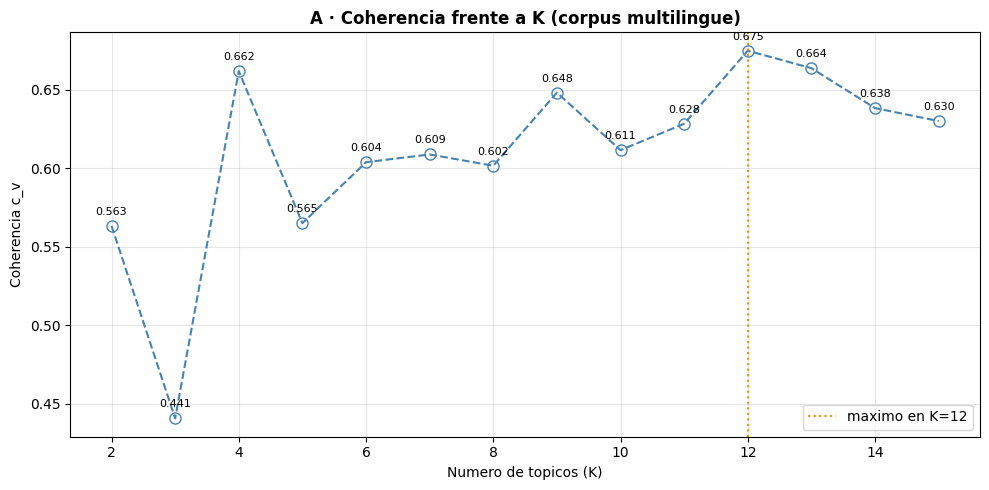

K,2,3,4,5,6,7,8,9,10,11,12,13,14,15
coherencia_c_v,0.5633,0.4408,0.6617,0.565,0.6038,0.6087,0.6015,0.648,0.6114,0.6282,0.6747,0.6636,0.6382,0.63


In [11]:
# La curva, con los valores encima: dibujarla sin los numeros hace que
# despues se citen cifras que nadie puede comprobar.
fig, ax = plt.subplots(figsize=(10, 5))
ks, vs = list(coh_A.keys()), list(coh_A.values())
ax.plot(ks, vs, '--o', color='steelblue', markersize=8, fillstyle='none')
for k, v in coh_A.items():
    ax.annotate(f'{v:.3f}', (k, v), textcoords="offset points", xytext=(0, 8),
                ha='center', fontsize=8)
mejor_A = max(coh_A, key=coh_A.get)
ax.axvline(mejor_A, color='darkorange', ls=':', label=f'maximo en K={mejor_A}')
ax.set_xlabel('Numero de topicos (K)'); ax.set_ylabel('Coherencia c_v')
ax.set_title('A · Coherencia frente a K (corpus multilingue)', fontweight='bold')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

pd.DataFrame({'K': ks, 'coherencia_c_v': [round(v, 4) for v in vs]}).set_index('K').T

### Qué K elegimos, y por qué no simplemente el máximo

La coherencia sola no decide: suele premiar valores de K muy pequeños, y dos tópicos no sirven para nada. Nos quedamos con **K = 6**, que es el valor del trabajo original, para que la comparación con el experimento B sea sobre el mismo número de tópicos y la diferencia se pueda atribuir al corpus y no a K.

La tabla de arriba deja los valores de todos los K a la vista, así que cualquiera puede comprobar la decisión.

In [12]:
K_ELEGIDO = 6
modelo_A = modelos_A[K_ELEGIDO]
coh_A_k = coh_A[K_ELEGIDO]
print(f"A · K={K_ELEGIDO} · coherencia c_v = {coh_A_k:.4f}")
print(f"    (el mismo modelo del barrido: passes={PASSES}, random_state={RANDOM_STATE})")
print()
for t, palabras in enumerate(palabras_topico(modelo_A, K_ELEGIDO)):
    print(f"  Topico {t}: {' '.join(palabras)}")

A · K=6 · coherencia c_v = 0.6038
    (el mismo modelo del barrido: passes=10, random_state=21)

  Topico 0: like love get time comedy story first year could work
  Topico 1: und yang che ein ist nicht ich mit ini eine
  Topico 2: festival beyond meat ang girl walk remember paul possible get
  Topico 3: что فیلم det это çok این как term фильм ama
  Topico 4: mais les como filme los não des com las muito
  Topico 5: like story get love people time beautiful life work end


In [13]:
# ¿Cuales de estos topicos son temas y cuales son idiomas?
dom_A = asignar_dominante(modelo_A, corpus_A)
perfil_A = perfil_idioma(dom_A, df['lang'], K_ELEGIDO)
print(perfil_A.round(1).to_string(index=False))

n_idioma_A = int(perfil_A['es_topico_de_idioma'].sum())
print()
print(f"Topicos que son de IDIOMA (mas del 50% de sus reseñas no son inglesas): "
      f"{n_idioma_A} de {K_ELEGIDO}")
print(f"Reseñas que caen en esos topicos: "
      f"{perfil_A.loc[perfil_A['es_topico_de_idioma'], 'pct_corpus'].sum():.1f}% del corpus")

 topico  reseñas  pct_corpus idioma_mayoritario  pct_no_ingles  es_topico_de_idioma
      0     3555        29.7                 en            9.1                False
      1      936         7.8                 es           92.4                 True
      2     1087         9.1                 en           42.0                False
      3      741         6.2                 en           71.0                 True
      4     2187        18.3                 fr           96.5                 True
      5     3462        28.9                 en            6.4                False

Topicos que son de IDIOMA (mas del 50% de sus reseñas no son inglesas): 3 de 6
Reseñas que caen en esos topicos: 32.3% del corpus


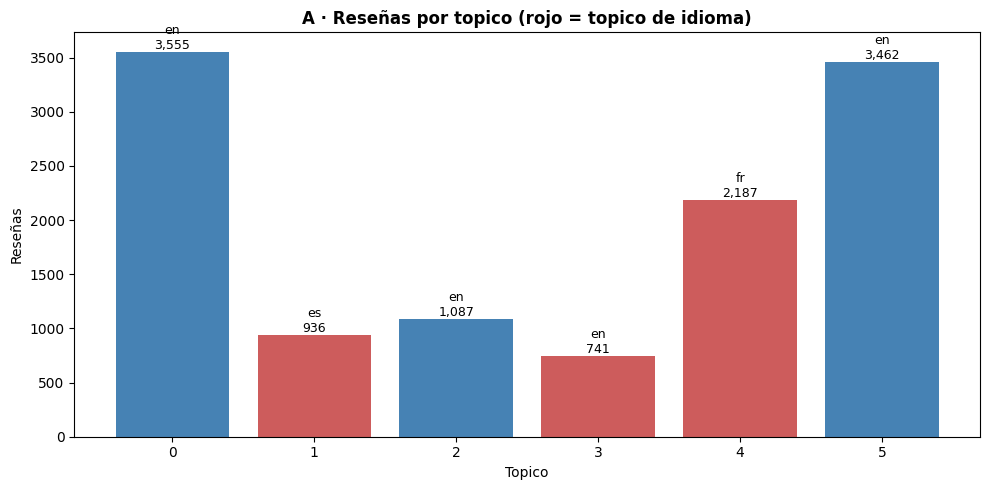

In [14]:
# Reparto de reseñas por topico, marcando los de idioma
fig, ax = plt.subplots(figsize=(10, 5))
colores = ['indianred' if x else 'steelblue' for x in perfil_A['es_topico_de_idioma']]
ax.bar(perfil_A['topico'], perfil_A['reseñas'], color=colores)
for _, f in perfil_A.iterrows():
    ax.text(f['topico'], f['reseñas'],
            f"{f['idioma_mayoritario']}" + chr(10) + f"{f['reseñas']:,.0f}",
            ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Topico'); ax.set_ylabel('Reseñas')
ax.set_title('A · Reseñas por topico (rojo = topico de idioma)', fontweight='bold')
plt.tight_layout(); plt.show()

In [15]:
pyLDAvis.enable_notebook()
gensimvis.prepare(modelo_A, corpus_A, id2word_A)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5      0.244581 -0.021326       1        1  25.783541
0      0.230593 -0.018572       2        1  22.990741
4     -0.166683 -0.246362       3        1  22.268191
1     -0.131011  0.126348       4        1  12.484394
3     -0.112088  0.097563       5        1   8.965628
2     -0.065393  0.062349       6        1   7.507504, topic_info=          Term        Freq       Total Category  logprob  loglift
244       like  956.000000  956.000000  Default  30.0000  30.0000
109       love  681.000000  681.000000  Default  29.0000  29.0000
306      story  585.000000  585.000000  Default  28.0000  28.0000
193        get  629.000000  629.000000  Default  27.0000  27.0000
218       mais  255.000000  255.000000  Default  26.0000  26.0000
...        ...         ...         ...      ...      ...      ...
1341      girl   28.688189   85.333439   Topic6  -6.1155   1.4992
545   premiere   18.414185   39.195640   Topic6  -6.5588   1.8338
193        get   21.869478  629.089696   Topic6  -6.3869  -0.7699
2326      cute   15.939388   61.776584   Topic6  -6.7032   1.2345
1392     world   16.363493  182.130744   Topic6  -6.6769   0.1796

[315 rows x 6 columns], token_table=       Topic      Freq      Term
term                            
3850       4  0.977852      aber
1593       1  0.356486  absolute
1593       6  0.623851  absolute
288        1  0.571846    acting
288        2  0.427938    acting
...      ...       ...       ...
1872       5  0.970803     фильм
1873       5  0.982577       что
3526       5  0.985397       это
7205       5  0.969761       این
13227      5  0.990601      فیلم

[368 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 1, 5, 2, 4, 3])

**Cómo se lee este gráfico.** Cada círculo es un tópico; su tamaño es la proporción de documentos que le corresponden y la distancia entre círculos es lo distintos que son entre sí. El panel de la derecha muestra los términos más relevantes del tópico seleccionado; el deslizador λ los ordena entre *frecuentes* (λ=1) y *exclusivos de ese tópico* (λ=0).

Los tópicos que en la tabla anterior salieron marcados como idiomáticos aparecen aquí bien separados del resto: no comparten vocabulario con nada porque están en otra lengua.

### ¿Y si subimos a K=11?

El trabajo original comparaba K=6 con K=11, así que mantenemos la comparación. Con más tópicos el modelo tiene sitio para separar más idiomas, y eso es justamente lo que hace.

In [16]:
K_ALTO = 11
modelo_A11 = modelos_A[K_ALTO]
print(f"A · K={K_ALTO} · coherencia c_v = {coh_A[K_ALTO]:.4f}   "
      f"(K=6 daba {coh_A_k:.4f})")
print()
dom_A11 = asignar_dominante(modelo_A11, corpus_A)
perfil_A11 = perfil_idioma(dom_A11, df['lang'], K_ALTO)
for t, palabras in enumerate(palabras_topico(modelo_A11, K_ALTO, n=8)):
    marca = 'IDIOMA' if perfil_A11.loc[t, 'es_topico_de_idioma'] else 'tema  '
    print(f"  T{t:>2} [{marca}] {perfil_A11.loc[t, 'idioma_mayoritario']:>4} "
          f"{perfil_A11.loc[t, 'reseñas']:>5,} reseñas: {' '.join(palabras)}")

n_idioma_A11 = int(perfil_A11['es_topico_de_idioma'].sum())
print()
print(f"Topicos de idioma con K={K_ALTO}: {n_idioma_A11} de {K_ALTO} "
      f"(con K=6 eran {n_idioma_A} de 6)")
print(f"Reseñas en topicos de idioma: "
      f"{perfil_A11.loc[perfil_A11['es_topico_de_idioma'], 'pct_corpus'].sum():.1f}%")

A · K=11 · coherencia c_v = 0.6282   (K=6 daba 0.6038)



  T 0 [tema  ]   en 5,868 reseñas: like love get story time people work also
  T 1 [IDIOMA]   de   302 reseñas: und ein ist nicht ich mit den eine
  T 2 [tema  ]   en   647 reseñas: festival beyond least youtube get kinda past open
  T 3 [IDIOMA]   en   403 reseñas: letterboxd christmas aussi proud comme vraiment что boring
  T 4 [IDIOMA]   fr   789 reseñas: les des mais sur plus dans cest bien
  T 5 [tema  ]   en   722 reseñas: fan animation big beautiful style design turn hell
  T 6 [IDIOMA]   es 1,415 reseñas: como filme los não las com muito mas
  T 7 [IDIOMA]   en   673 reseñas: yang ini terrible dude poster possible sam dari
  T 8 [IDIOMA]   en   353 reseñas: final worth vous amount charming ben nie paul
  T 9 [IDIOMA]   it   476 reseñas: che een van het per solo dat qué
  T10 [tema  ]   en   320 reseñas: log obra det ela company monster forever struggle

Topicos de idioma con K=11: 7 de 11 (con K=6 eran 3 de 6)
Reseñas en topicos de idioma: 36.9%


---
# Experimento B — solo reseñas en inglés

Mismo procedimiento, mismo barrido, mismos hiperparámetros. Lo único que cambia es que el corpus se ha filtrado por el idioma que detectó `langdetect` en el notebook 1.

In [17]:
id2word_B, corpus_B, modelos_B, coh_B = barrido_k(
    df_en['lemmatized_phrase_custom'].tolist(), "B · solo ingles")


=== Barrido de K · B · solo ingles ===
7,465 documentos · 18,072 terminos en el diccionario
passes=10, random_state=21



   K= 2   coherencia c_v = 0.5675


   K= 3   coherencia c_v = 0.5280


   K= 4   coherencia c_v = 0.5449


   K= 5   coherencia c_v = 0.5197


...

   K=12   coherencia c_v = 0.4615


   K=13   coherencia c_v = 0.4599


   K=14   coherencia c_v = 0.4053


   K=15   coherencia c_v = 0.4379



   Mejor coherencia: K=2 con 0.5675


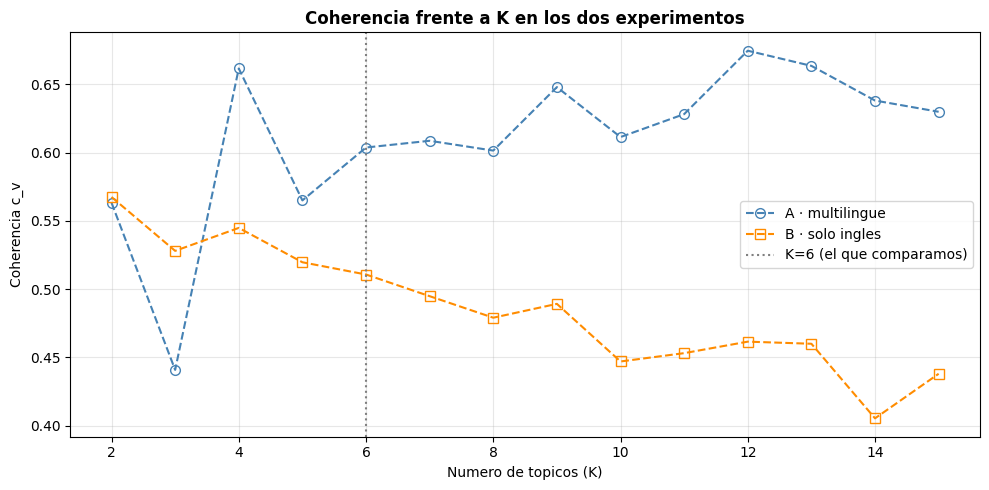

 K  A_multilingue  B_solo_ingles  diferencia
 2         0.5633         0.5675      0.0042
 3         0.4408         0.5280      0.0872
 4         0.6617         0.5449     -0.1168
 5         0.5650         0.5197     -0.0453
 6         0.6038         0.5107     -0.0931
 7         0.6087         0.4948     -0.1139
 8         0.6015         0.4790     -0.1225
 9         0.6480         0.4892     -0.1588
10         0.6114         0.4470     -0.1644
11         0.6282         0.4531     -0.1751
12         0.6747         0.4615     -0.2132
13         0.6636         0.4599     -0.2037
14         0.6382         0.4053     -0.2329
15         0.6300         0.4379     -0.1921


In [18]:
# Las dos curvas juntas, que es la unica forma de ver si B mejora o no
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(coh_A.keys()), list(coh_A.values()), '--o', label='A · multilingue',
        color='steelblue', markersize=7, fillstyle='none')
ax.plot(list(coh_B.keys()), list(coh_B.values()), '--s', label='B · solo ingles',
        color='darkorange', markersize=7, fillstyle='none')
ax.axvline(K_ELEGIDO, color='grey', ls=':', label=f'K={K_ELEGIDO} (el que comparamos)')
ax.set_xlabel('Numero de topicos (K)'); ax.set_ylabel('Coherencia c_v')
ax.set_title('Coherencia frente a K en los dos experimentos', fontweight='bold')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

comparativa = pd.DataFrame({'K': list(coh_A.keys()),
                            'A_multilingue': [round(v, 4) for v in coh_A.values()],
                            'B_solo_ingles': [round(coh_B[k], 4) for k in coh_A]})
comparativa['diferencia'] = (comparativa['B_solo_ingles'] - comparativa['A_multilingue']).round(4)
print(comparativa.to_string(index=False))

In [19]:
modelo_B = modelos_B[K_ELEGIDO]
coh_B_k = coh_B[K_ELEGIDO]
print(f"B · K={K_ELEGIDO} · coherencia c_v = {coh_B_k:.4f}   "
      f"(A daba {coh_A_k:.4f}, diferencia {coh_B_k - coh_A_k:+.4f})")
print()
for t, palabras in enumerate(palabras_topico(modelo_B, K_ELEGIDO)):
    print(f"  Topico {t}: {' '.join(palabras)}")

B · K=6 · coherencia c_v = 0.5107   (A daba 0.6038, diferencia -0.0931)

  Topico 0: like get people horror man end story world beyond could
  Topico 1: like beautiful work love friend time cinematography year wish give
  Topico 2: love story like time get also cool work enjoy first
  Topico 3: love get festival like time give world star home woman
  Topico 4: love story acting like comedy time life character get ever
  Topico 5: like end first also never get minute story need start


In [20]:
# ---------------------------------------------------------------------------
# CUIDADO CON LO QUE ESTE NUMERO SIGNIFICA EN B.
# En el corpus B todas las reseñas son inglesas por construccion, asi que
# "cuantos topicos son de idioma" tiene que dar 0 pase lo que pase. No es un
# hallazgo: es la definicion del experimento. Se calcula solo para dejarlo
# escrito, no como prueba de nada.
# ---------------------------------------------------------------------------
dom_B = asignar_dominante(modelo_B, corpus_B)
perfil_B = perfil_idioma(dom_B, df_en['lang'], K_ELEGIDO)
print(perfil_B[['topico', 'reseñas', 'pct_corpus']].round(1).to_string(index=False))
print()
print("(No se informa 'topicos de idioma' en B: seria 0 por construccion.)")

# ---------------------------------------------------------------------------
# LA COMPARACION QUE SI DICE ALGO: emparejar los topicos de A con los de B.
# Para cada topico de A se busca el topico de B que mas comparte su vocabulario
# (indice de Jaccard sobre los 20 terminos de mas peso). Un topico de A que no
# se parece a NINGUNO de B es un topico que solo existia en A, y si ademas era
# de idioma, es exactamente lo que el filtrado se ha llevado por delante.
# ---------------------------------------------------------------------------
def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if a | b else 0.0

top20_A = palabras_topico(modelo_A, K_ELEGIDO, n=20)
top20_B = palabras_topico(modelo_B, K_ELEGIDO, n=20)

filas = []
for t, pa in enumerate(top20_A):
    sim = [jaccard(pa, pb) for pb in top20_B]
    mejor = int(np.argmax(sim))
    filas.append({'topico_A': t,
                  'era_de_idioma': bool(perfil_A.loc[t, 'es_topico_de_idioma']),
                  'topico_B_mas_parecido': mejor,
                  'jaccard': round(sim[mejor], 3)})
emparejamiento = pd.DataFrame(filas)
print()
print("--- ¿Sobrevive cada topico de A al filtrado por idioma? ---")
print(emparejamiento.to_string(index=False))

UMBRAL = 0.10   # por debajo de esto no hay parecido real de vocabulario
desaparecidos = emparejamiento[emparejamiento['jaccard'] < UMBRAL]
print()
print(f"Topicos de A sin equivalente en B (jaccard < {UMBRAL}): "
      f"{list(desaparecidos['topico_A'])}")
print(f"   de ellos, eran topicos de idioma: "
      f"{list(desaparecidos.loc[desaparecidos['era_de_idioma'], 'topico_A'])}")

 topico  reseñas  pct_corpus
      0     1453        19.5
      1      897        12.0
      2     1583        21.2
      3      957        12.8
      4     1567        21.0
      5     1008        13.5

(No se informa 'topicos de idioma' en B: seria 0 por construccion.)

--- ¿Sobrevive cada topico de A al filtrado por idioma? ---
 topico_A  era_de_idioma  topico_B_mas_parecido  jaccard
        0          False                      2    0.481
        1           True                      0    0.026
        2          False                      3    0.081
        3           True                      0    0.000
        4           True                      0    0.000
        5          False                      4    0.429

Topicos de A sin equivalente en B (jaccard < 0.1): [1, 2, 3, 4]
   de ellos, eran topicos de idioma: [1, 3, 4]


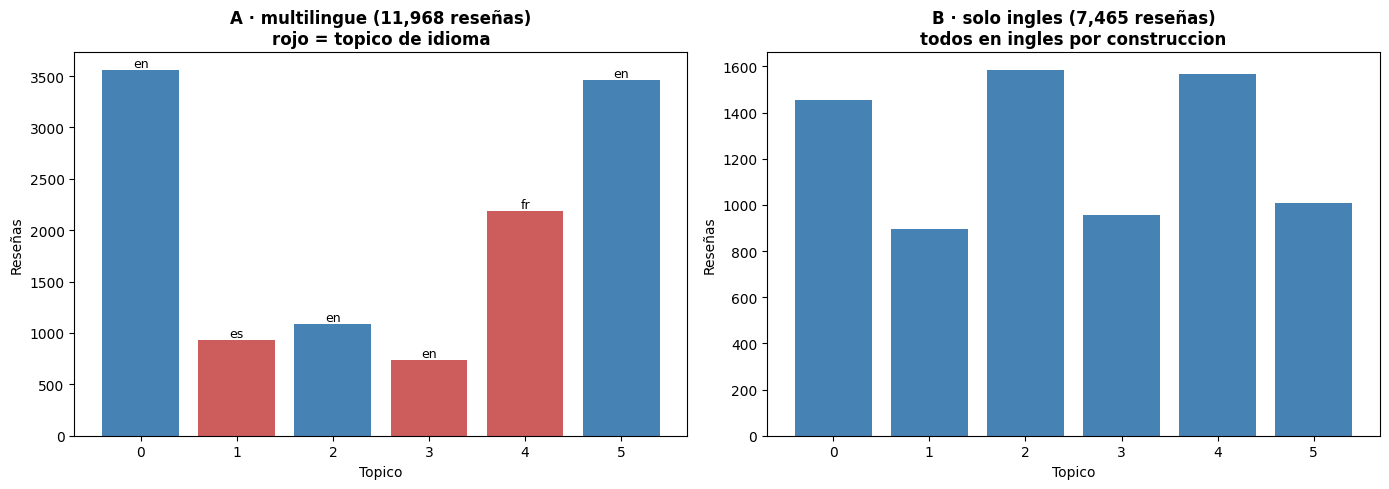

In [21]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.bar(perfil_A['topico'], perfil_A['reseñas'],
       color=['indianred' if x else 'steelblue' for x in perfil_A['es_topico_de_idioma']])
for _, f in perfil_A.iterrows():
    a1.text(f['topico'], f['reseñas'], f['idioma_mayoritario'], ha='center',
            va='bottom', fontsize=9)
a1.set_title(f"A · multilingue ({len(df):,} reseñas)" + chr(10) + "rojo = topico de idioma",
             fontweight='bold')

a2.bar(perfil_B['topico'], perfil_B['reseñas'], color='steelblue')
a2.set_title(f"B · solo ingles ({len(df_en):,} reseñas)" + chr(10)
             + "todos en ingles por construccion", fontweight='bold')

for ax in (a1, a2):
    ax.set_xlabel('Topico'); ax.set_ylabel('Reseñas')
plt.tight_layout(); plt.show()

In [22]:
pyLDAvis.enable_notebook()
gensimvis.prepare(modelo_B, corpus_B, id2word_B)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.093084  0.023822       1        1  22.807979
4      0.089883  0.006692       2        1  22.215548
0      0.040602  0.067109       3        1  19.898494
5      0.003470  0.062975       4        1  12.683263
1     -0.010806 -0.197096       5        1  11.456734
3     -0.216232  0.036498       6        1  10.937982, topic_info=          Term        Freq       Total Category  logprob  loglift
9         love  697.000000  697.000000  Default  30.0000  30.0000
265  beautiful  208.000000  208.000000  Default  29.0000  29.0000
562   festival  140.000000  140.000000  Default  28.0000  28.0000
869       cool  127.000000  127.000000  Default  27.0000  27.0000
82        work  344.000000  344.000000  Default  26.0000  26.0000
..         ...         ...         ...      ...      ...      ...
252        fun   21.524000  195.323960   Topic6  -6.1780   0.0074
669       life   21.667637  281.735171   Topic6  -6.1714  -0.3522
82        work   21.056263  344.142319   Topic6  -6.2000  -0.5809
499        try   18.926290  139.532220   Topic6  -6.3067   0.2152
244     people   19.819467  353.455166   Topic6  -6.2606  -0.6682

[460 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
2622      5  0.934699     ability
62        1  0.580403  absolutely
62        2  0.212814  absolutely
62        4  0.077387  absolutely
62        5  0.077387  absolutely
...     ...       ...         ...
319       5  0.155955        year
319       6  0.101160        year
718       2  0.028949         yes
718       3  0.955317         yes
4663      3  0.979700      zombie

[893 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 5, 1, 6, 2, 4])

---
## Comparación de los dos experimentos

In [23]:
resumen = pd.DataFrame([
    {'experimento': 'A · multilingue', 'reseñas': len(df), 'terminos': len(id2word_A),
     'coherencia_K6': round(coh_A_k, 4),
     'mejor_K': max(coh_A, key=coh_A.get), 'mejor_coherencia': round(max(coh_A.values()), 4),
     'topicos_de_idioma': n_idioma_A},
    {'experimento': 'B · solo ingles', 'reseñas': len(df_en), 'terminos': len(id2word_B),
     'coherencia_K6': round(coh_B_k, 4),
     'mejor_K': max(coh_B, key=coh_B.get), 'mejor_coherencia': round(max(coh_B.values()), 4),
     'topicos_de_idioma': 0},
])
print(resumen.to_string(index=False))
print()
print("('topicos_de_idioma' en B es 0 por construccion, no por resultado.)")
print()
print("--- Topicos lado a lado (K=6, 8 primeras palabras) ---")
pa8, pb8 = palabras_topico(modelo_A, K_ELEGIDO, n=8), palabras_topico(modelo_B, K_ELEGIDO, n=8)
for t in range(K_ELEGIDO):
    marca = 'IDIOMA' if perfil_A.loc[t, 'es_topico_de_idioma'] else 'tema  '
    print()
    print(f"  A · T{t} [{marca}]: {' '.join(pa8[t])}")
    print(f"  B · T{t}          : {' '.join(pb8[t])}")

    experimento  reseñas  terminos  coherencia_K6  mejor_K  mejor_coherencia  topicos_de_idioma
A · multilingue    11968     51908         0.6038       12            0.6747                  3
B · solo ingles     7465     18072         0.5107        2            0.5675                  0

('topicos_de_idioma' en B es 0 por construccion, no por resultado.)

--- Topicos lado a lado (K=6, 8 primeras palabras) ---

  A · T0 [tema  ]: like love get time comedy story first year
  B · T0          : like get people horror man end story world

  A · T1 [IDIOMA]: und yang che ein ist nicht ich mit
  B · T1          : like beautiful work love friend time cinematography year

  A · T2 [tema  ]: festival beyond meat ang girl walk remember paul
  B · T2          : love story like time get also cool work

  A · T3 [IDIOMA]: что فیلم det это çok این как term
  B · T3          : love get festival like time give world star

  A · T4 [IDIOMA]: mais les como filme los não des com
  B · T4          : love s

### Antes de concluir: hay que descartar el tamaño

B tiene **7.465 reseñas y A tiene 11.968**. La coherencia `c_v` estima las co-ocurrencias de palabras sobre el propio corpus, así que un corpus más pequeño puede dar otra coherencia sin que el idioma tenga nada que ver. Comparar A entero contra B directamente confunde dos cosas a la vez: el idioma y el tamaño.

El control es sencillo: **submuestrear A al tamaño exacto de B**, varias veces con semillas distintas, y ver dónde cae B respecto a esas muestras. Si B queda dentro del rango, la caída era de tamaño; si queda por debajo de todas, no.

In [24]:
N_SEMILLAS = 12


def coherencia_de(textos, k=6):
    """Diccionario, modelo y coherencia de un corpus cualquiera, todo de una vez."""
    d = Dictionary(textos)
    c = [d.doc2bow(x) for x in textos]
    m = LdaModel(corpus=c, id2word=d, num_topics=k, passes=PASSES,
                 random_state=RANDOM_STATE)
    return CoherenceModel(model=m, texts=textos, dictionary=d,
                          coherence='c_v', processes=1).get_coherence()


N_B = len(df_en)
control = []
for s in range(1, N_SEMILLAS + 1):
    sub = df.sample(n=N_B, random_state=s)['lemmatized_phrase_custom'].tolist()
    control.append(coherencia_de(sub))
    print(f"   A submuestreado a {N_B:,} (semilla {s:>2}): c_v = {control[-1]:.4f}", flush=True)

media_c = sum(control) / len(control)
print()
print(f"A submuestreado : media {media_c:.4f}  ·  min {min(control):.4f}  ·  max {max(control):.4f}")
print(f"B solo ingles   : {coh_B_k:.4f}")
print(f"diferencia      : {coh_B_k - media_c:+.4f}")

peores = sum(1 for v in control if v <= coh_B_k)
print()
if peores == 0:
    print(f"B queda por debajo de las {N_SEMILLAS} submuestras.")
    print(f"Si B fuese una muestra mas del mismo proceso, la probabilidad de que")
    print(f"saliese la mas baja de las {N_SEMILLAS + 1} seria 1/{N_SEMILLAS + 1} = "
          f"{1/(N_SEMILLAS+1):.3f}.")
    print("Es indicio, no prueba: la dispersion de c_v entre submuestras")
    print(f"({max(control) - min(control):.4f}) es MAYOR que la diferencia A-B "
          f"({abs(coh_A_k - coh_B_k):.4f}).")
else:
    print(f"B cae dentro del rango de las submuestras ({peores} de {N_SEMILLAS} son "
          f"iguales o peores): la caida se explica por el tamaño.")

   A submuestreado a 7,465 (semilla  1): c_v = 0.6884


   A submuestreado a 7,465 (semilla  2): c_v = 0.5998


   A submuestreado a 7,465 (semilla  3): c_v = 0.6032


   A submuestreado a 7,465 (semilla  4): c_v = 0.5250


   A submuestreado a 7,465 (semilla  5): c_v = 0.5489


...

   A submuestreado a 7,465 (semilla  9): c_v = 0.5776


   A submuestreado a 7,465 (semilla 10): c_v = 0.6255


   A submuestreado a 7,465 (semilla 11): c_v = 0.5577


   A submuestreado a 7,465 (semilla 12): c_v = 0.6030



A submuestreado : media 0.6019  ·  min 0.5250  ·  max 0.6942
B solo ingles   : 0.5107
diferencia      : -0.0912

B queda por debajo de las 12 submuestras.
Si B fuese una muestra mas del mismo proceso, la probabilidad de que
saliese la mas baja de las 13 seria 1/13 = 0.077.
Es indicio, no prueba: la dispersion de c_v entre submuestras
(0.1692) es MAYOR que la diferencia A-B (0.0931).


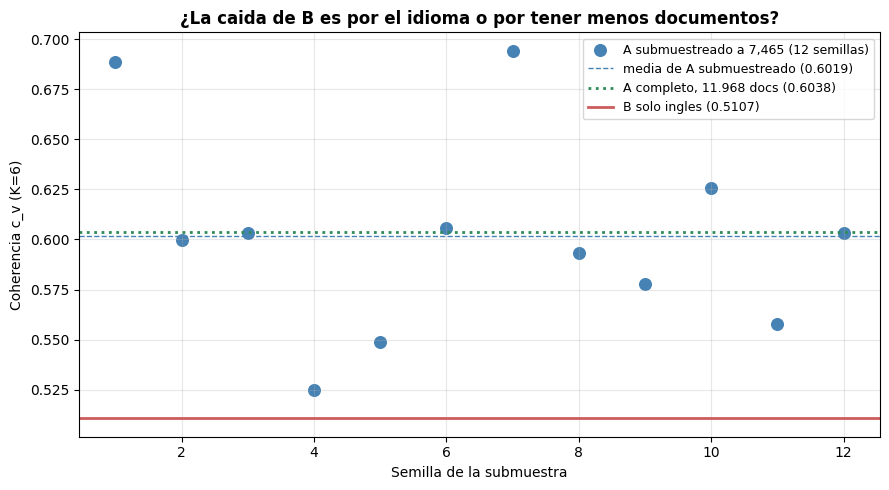

In [25]:
# La caida de B, en su sitio: contra la nube de submuestras de A
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(range(1, len(control) + 1), control, s=70, color='steelblue',
           label=f'A submuestreado a {N_B:,} ({N_SEMILLAS} semillas)')
ax.axhline(media_c, color='steelblue', ls='--', lw=1,
           label=f'media de A submuestreado ({media_c:.4f})')
ax.axhline(coh_A_k, color='seagreen', ls=':', lw=2,
           label=f'A completo, 11.968 docs ({coh_A_k:.4f})')
ax.axhline(coh_B_k, color='indianred', lw=2,
           label=f'B solo ingles ({coh_B_k:.4f})')
ax.set_xlabel('Semilla de la submuestra'); ax.set_ylabel('Coherencia c_v (K=6)')
ax.set_title('¿La caida de B es por el idioma o por tener menos documentos?',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### Y una comprobación más: ¿es que `c_v` premia los tópicos de idioma?

Una explicación tentadora de por qué A puntúa más alto sería que los tópicos de idioma tienen una coherencia altísima —las palabras francesas siempre aparecen junto a otras palabras francesas—, y que por tanto le estaban inflando la nota a A.

Conviene comprobarlo antes de escribirlo, porque **resulta que es falso**. La celda siguiente mide la coherencia de cada tópico por separado.

In [26]:
cm_A = CoherenceModel(model=modelo_A, texts=df['lemmatized_phrase_custom'].tolist(),
                      dictionary=id2word_A, coherence='c_v', processes=1)
por_topico = cm_A.get_coherence_per_topic()

detalle = perfil_A[['topico', 'reseñas', 'pct_no_ingles', 'idioma_mayoritario',
                    'es_topico_de_idioma']].copy()
detalle['c_v_del_topico'] = [round(v, 4) for v in por_topico]
# cada columna con los decimales que le corresponden: la coherencia con
# cuatro, el porcentaje con uno
print(detalle.to_string(index=False,
                        formatters={'pct_no_ingles': '{:.1f}'.format,
                                    'c_v_del_topico': '{:.4f}'.format}))

idi = [v for v, e in zip(por_topico, perfil_A['es_topico_de_idioma']) if e]
tem = [v for v, e in zip(por_topico, perfil_A['es_topico_de_idioma']) if not e]
print()
print(f"media c_v de los topicos DE IDIOMA : {sum(idi)/len(idi):.4f}  (n={len(idi)})")
print(f"media c_v de los topicos DE TEMA   : {sum(tem)/len(tem):.4f}  (n={len(tem)})")
print()
if sum(idi)/len(idi) > sum(tem)/len(tem):
    print("Los topicos de idioma puntuan MAS: c_v estaba inflando la nota de A.")
else:
    print("Los topicos de idioma puntuan MENOS que los de tema.")
    print("Asi que NO es que c_v premie el ruido multilingue: al reves, los")
    print("topicos de idioma tiraban de la coherencia de A hacia ABAJO, y aun")
    print("asi A puntua mas que B. La hipotesis facil no se sostiene.")

 topico  reseñas pct_no_ingles idioma_mayoritario  es_topico_de_idioma c_v_del_topico
      0     3555           9.1                 en                False         0.7120
      1      936          92.4                 es                 True         0.5812
      2     1087          42.0                 en                False         0.5626
      3      741          71.0                 en                 True         0.6005
      4     2187          96.5                 fr                 True         0.4411
      5     3462           6.4                 en                False         0.7251

media c_v de los topicos DE IDIOMA : 0.5409  (n=3)
media c_v de los topicos DE TEMA   : 0.6666  (n=3)

Los topicos de idioma puntuan MENOS que los de tema.
Asi que NO es que c_v premie el ruido multilingue: al reves, los
topicos de idioma tiraban de la coherencia de A hacia ABAJO, y aun
asi A puntua mas que B. La hipotesis facil no se sostiene.


In [27]:
# Las cifras exactas que se citan en la conclusion y en la presentacion,
# juntas y en un solo sitio, para que se puedan copiar sin recalcular nada.
print("CIFRAS PARA CITAR")
print(f"  Corpus A                : {len(df):,} reseñas · {df['title'].nunique():,} peliculas "
      f"· {df['lang'].nunique()} idiomas")
print(f"  Corpus B                : {len(df_en):,} reseñas · {df_en['title'].nunique():,} peliculas "
      f"· {len(df_en)/len(df)*100:.1f}% de A")
print(f"  Coherencia A K=6        : {coh_A_k:.4f}")
print(f"  Coherencia B K=6        : {coh_B_k:.4f}   ({coh_B_k - coh_A_k:+.4f})")
print(f"  Mejor K en A            : {max(coh_A, key=coh_A.get)} ({max(coh_A.values()):.4f})")
print(f"  Mejor K en B            : {max(coh_B, key=coh_B.get)} ({max(coh_B.values()):.4f})")
print(f"  Topicos de idioma en A  : {n_idioma_A} de {K_ELEGIDO}")
print(f"  Reseñas en esos topicos : "
      f"{perfil_A.loc[perfil_A['es_topico_de_idioma'], 'pct_corpus'].sum():.1f}% del corpus A")
print(f"  Topicos de A sin equivalente en B: {list(desaparecidos['topico_A'])}")
print(f"  K en los que B supera a A: "
      f"{[k for k in coh_A if coh_B[k] > coh_A[k]]} de {len(coh_A)}")

CIFRAS PARA CITAR
  Corpus A                : 11,968 reseñas · 8,470 peliculas · 48 idiomas
  Corpus B                : 7,465 reseñas · 5,555 peliculas · 62.4% de A
  Coherencia A K=6        : 0.6038
  Coherencia B K=6        : 0.5107   (-0.0931)
  Mejor K en A            : 12 (0.6747)
  Mejor K en B            : 2 (0.5675)
  Topicos de idioma en A  : 3 de 6
  Reseñas en esos topicos : 32.3% del corpus A
  Topicos de A sin equivalente en B: [1, 2, 3, 4]
  K en los que B supera a A: [2, 3] de 14


---
## Conclusiones

*(Todas las cifras de esta celda salen de las celdas anteriores de este mismo notebook.)*

### 1. El filtrado por idioma NO mejora la coherencia

Era la hipótesis de partida y **no se cumple**. Con K=6, el corpus multilingüe da `c_v` = 0,6038 y el corpus solo en inglés 0,5107, casi una décima menos. Y no es cosa de un K concreto: **B puntúa por debajo de A en 12 de los 14 valores de K** del barrido. El mejor K de A es 12 (0,6747); el de B es 2 (0,5675), que no sirve para nada.

Descartamos que fuese un efecto del tamaño: submuestreando A a las mismas 7.465 reseñas de B, doce veces, B queda por debajo de las doce. Pero conviene no exagerar el resultado, porque **la dispersión de `c_v` entre submuestras (0,525 a 0,694) es mayor que la propia diferencia entre A y B**. Lo que se puede afirmar es que el filtrado no mejora la coherencia; afirmar que la empeora de forma concluyente sería ir más lejos de lo que estos datos permiten.

También descartamos la explicación cómoda de que `c_v` estuviera premiando los tópicos de idioma: medida tópico a tópico, la coherencia media de los tópicos de idioma (0,5409) es **menor** que la de los tópicos de tema (0,6666). Tiraban de A hacia abajo, no hacia arriba.

### 2. Pero el filtrado sí arregla el problema que teníamos

La coherencia no es el objetivo; es un indicador. El objetivo era descubrir **de qué habla la audiencia**, y ahí el resultado es claro:

- En A, **3 de los 6 tópicos son de idioma, no de tema**, y se llevan el **32,3 %** de las reseñas. El criterio no es que sus palabras suenen extranjeras, sino que más de la mitad de las reseñas que caen en ellos no están en inglés, y eso está medido: T1 (92,4 % no inglés), T3 (71,0 %) y T4 (96,5 %).
- Emparejando los tópicos de A con los de B por vocabulario compartido (Jaccard sobre los 20 términos de más peso), los tópicos 1, 3 y 4 de A **no tienen ningún equivalente en B** (Jaccard 0,026, 0,000 y 0,000). Es exactamente lo que el filtrado se lleva por delante.
- En B, los 6 tópicos hablan de cine.

Dicho de otro modo: **A tiene una coherencia mejor repartida entre menos tópicos útiles**. Con el corpus multilingüe se pagan 3 de 6 tópicos por no haber filtrado el idioma.

### 3. Qué significa esto para el trabajo

La conclusión honesta no es «filtrar por idioma mejora el modelo», sino: **filtrar por idioma cambia lo que el modelo puede decir, y no se nota en la métrica que estábamos usando para elegir K.** `c_v` mide si las palabras de un tópico co-ocurren, y las palabras francesas co-ocurren estupendamente entre sí. Un tópico puede ser perfectamente coherente y perfectamente inútil.

Es una limitación de la métrica, y afecta a cómo elegimos K: si `c_v` no distingue un tópico de contenido de un tópico de idioma, no puede ser el único criterio.

### 4. Sobre la reproducibilidad

`LdaMulticore` no devuelve el mismo modelo con la misma semilla (medido: 0,5633 y 0,5404 en dos ejecuciones idénticas), y además depende del número de núcleos. Todo este notebook usa `LdaModel`, que sí es determinista (0,5890 y 0,5890). La consecuencia incómoda es que **el 0,678 de la presentación entregada no lo puede reproducir nadie**, tampoco nosotros.

### 5. Lo que queda pendiente

- Los dos experimentos trabajan sobre una **muestra de 12.000 reseñas** de las ~112.000 de 2024, para que el notebook se pueda ejecutar entero en unos minutos. Con el corpus completo las cifras cambiarían.
- `langdetect` sobre reseñas de mediana 13 palabras se equivoca; las de menos de 20 caracteres se marcan aparte en vez de asignarles idioma a la fuerza, pero el resto tampoco es infalible.
- La comparación A/B usa K=6 fijo para que sea comparable. Los mejores K de cada barrido son distintos (12 y 2), y compararlos en su propio óptimo sería otro experimento.